# Bài thực hành 1 - Số liệu thống kê
Nhóm 13:
- Vũ Bảo Khôi - 202419071
- Quách Bảo Lâm - 202419075
## 1. Thông tin bộ dữ liệu

Bộ dữ liệu được lấy từ trang web Kaggle, nghiên cứu 4500 học sinh từ trung học tới đại học về ảnh hưởng của các nền tảng mạng xã hội lên cuộc sống của họ.

Bộ dữ liệu thực tế đo 16 danh mục, nhưng trong khuôn khổ bài thực hành nhóm chỉ lấy các danh mục sau để tiến hành phân tính
- Student_ID (String): Mã định danh cho học sinh
- Age(Integer): độ tuổi (nằm trong khoảng từ 16-25 tuổi) - biến định lượng
- Daily_Usage_Hours(Float): thời gian sử dụng mạng xã hội hằng ngày - biến định lượng
- Late_Night_Usage(Booleen): Có sử dụng mạng xã hội qua đêm không - biến định tính

## 2. Xử lí số liệu
### 2.1. Nhập dữ liệu

In [2]:
import pandas as pd

df = pd.read_csv('Social_media_impact_on_life.csv')
columns_to_extract = ['Student_ID', 'Age', 'Daily_Usage_Hours', 'Late_Night_Usage']
df_subset = df[columns_to_extract].copy()

df_subset['Age'] = pd.to_numeric(df_subset['Age'], errors='coerce').round().astype('Int64')
df_subset['Daily_Usage_Hours'] = pd.to_numeric(df_subset['Daily_Usage_Hours'], errors='coerce').round().astype('float64')
df_subset['Student_ID'] = df_subset['Student_ID'].astype('string')
df_subset['Late_Night_Usage'] = df_subset['Late_Night_Usage'].astype('bool')

student_ids = df_subset['Student_ID'].tolist()
ages = df_subset['Age'].tolist()
daily_usages = df_subset['Daily_Usage_Hours'].tolist()
late_night_usages = df_subset['Late_Night_Usage'].tolist()

print("Mảng Student ID:", student_ids[:5])
print("Mảng Age:", ages[:5])
print("Mảng Daily Usage:", daily_usages[:5])
print("Mảng Late Night:", late_night_usages[:10])

Mảng Student ID: ['STU_2024000', 'STU_2024001', 'STU_2024002', 'STU_2024003', 'STU_2024004']
Mảng Age: [19, 19, 17, 16, 17]
Mảng Daily Usage: [8.0, 5.0, 11.0, 6.0, 3.0]
Mảng Late Night: [True, True, True, True, True, False, False, False, False, False]


### 2.2. Với một biến định lượng, ước lượng kỳ vọng tổng thể bằng khoảng tin cậy 95%.
Gọi X là biến ngẫu nhiên đại diện cho thời gian sử dụng mạng xã hội hàng ngày của sinh viên.

$\overline{X}$ là biến ngẫu nhiên đại diện cho thời gian trung bình sử dụng mạng xã hội.

Vì $E(\overline{x}) = \mu \Rightarrow \overline{X}$ là ước lượng không chệch cho kỳ vọng tổng thể $\mu$

Vì n đủ lớn ($n=4500>30$), áp dụng định lý giới hạn giá trị trung tâm ta có:

$\overline{X} \sim N(\mu, \dfrac{\sigma ^2}{n})$

Thành lập mẫu ngẫu nhiên $W_X = (X_1, X_2,....,X_{4500})$, cỡ mẫu $n=4500$

Chuẩn hóa: $ Z = \dfrac{\overline{X} - \mu}{\sigma}$

Độ tin cậy 95% $\Rightarrow 1-\alpha = 0.95 \Rightarrow \alpha = 0.05$

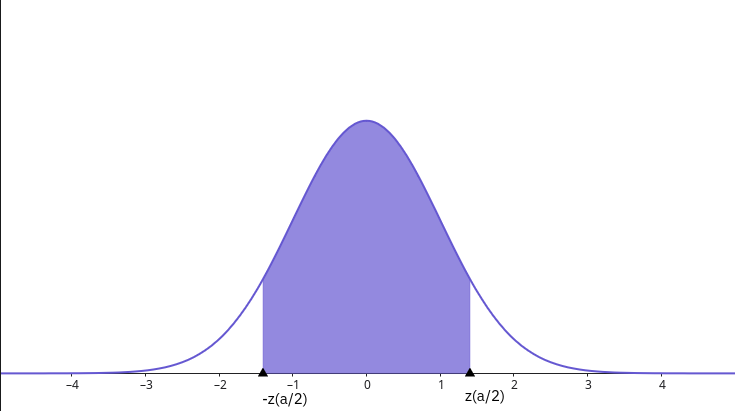

Khoảng tin cậy đối xứng cho kì vọng tổng thể:

$ -Z_{\dfrac{\alpha}{2}} < Z < Z_{\dfrac{\alpha}{2}}$

